## Exploratory Data Analysis of Flight Delay Dataset


### Display of Cleaned Dataset

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

con = duckdb.connect()
df = con.execute("SELECT * FROM '../data/flights_clean.parquet'").df()

df.head(15)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Year,Quarter,Month,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,CRSArrTime,DepDelay,Cancelled,CancellationCode,Diverted,Distance
0,2024,1,1,2024-01-08,9E,LGA,OMA,856,1135,-5.0,0.0,None,0.0,1148.0
1,2024,1,1,2024-01-09,9E,LGA,OMA,856,1135,-5.0,0.0,None,0.0,1148.0
2,2024,1,1,2024-01-10,9E,LGA,OMA,856,1135,-6.0,0.0,None,0.0,1148.0
3,2024,1,1,2024-01-11,9E,LGA,OMA,856,1135,23.0,0.0,None,0.0,1148.0
4,2024,1,1,2024-01-12,9E,LGA,OMA,856,1135,-5.0,0.0,None,0.0,1148.0
5,2024,1,1,2024-01-15,9E,LGA,OMA,856,1135,23.0,0.0,None,0.0,1148.0
6,2024,1,1,2024-01-17,9E,LGA,OMA,856,1135,27.0,0.0,None,0.0,1148.0
7,2024,1,1,2024-01-18,9E,LGA,OMA,856,1135,-3.0,0.0,None,0.0,1148.0
8,2024,1,1,2024-01-19,9E,LGA,OMA,856,1135,-15.0,0.0,None,0.0,1148.0
9,2024,1,1,2024-01-22,9E,LGA,OMA,856,1135,-3.0,0.0,None,0.0,1148.0


We first load the cleaned dataset to confirm its structure before analysis. The DataFrame contains key flight operation fields including Year, Quarter, Month, FlightDate, Reporting_Airline, Origin, Dest, CRSDepTime, CRSArrTime, DepDelay, Cancelled, CancellationCode, Diverted, and Distance.
From the initial rows displayed, the dataset covers 2024 flight records operated by US Airlines for different routes. Notable observations at this beginning stage include:
- **DepDelay** values contain both negative numbers for early departures and positive numbers for actual delays, confirming that the column captures the full range of departure timing.
- **Cancelled** is recorded as 0.0 across the visible rows and the CancellationCode shows None, indicating that this field is an accurate representation for flight cancellation records.
- **CRSDepTime** and **CRSArrTime** are consistent at 856 and 1135 respectively across the displayed rows, suggesting this is a scheduled recurring flight.
- The index is reset and sequential confirming rows were cleaned and reindexed properly using sql. 

### Distribution Analysis of Departure Delay

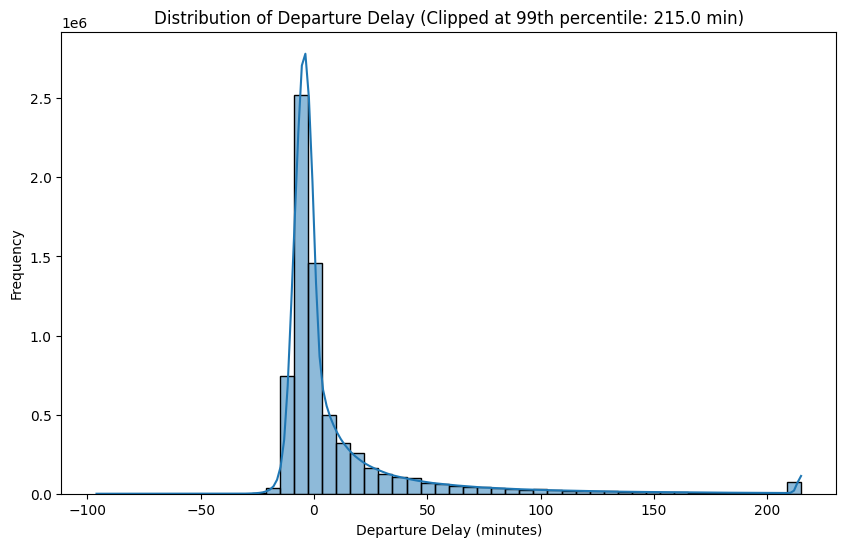

Percentage of delayed flights (>= 15 min): 20.60%


In [2]:
# Distribution of DepDelay
plt.figure(figsize=(10, 6))
# Clip at 99th percentile to visualize without extreme outliers
upper_limit = df['DepDelay'].quantile(0.99)
sns.histplot(df['DepDelay'].clip(upper=upper_limit), bins=50, kde=True)
plt.title(f'Distribution of Departure Delay (Clipped at 99th percentile: {upper_limit:.1f} min)')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Frequency')
plt.show()

# % of flights where DepDelay >= 15 (FAA "delayed" threshold)
delayed_ratio = (df['DepDelay'] >= 15).mean() * 100
print(f"Percentage of delayed flights (>= 15 min): {delayed_ratio:.2f}%")

To examine the distribution of departure delays, the data was clipped at the 99th percentile, which is 215.0 minutes, to reduce the visual distortion caused by extreme outliers, while stil preserving the realistic spread of the data.
The resulting histogram describes a right-skewed distribution, with the bulk of flights concentrated near 0 minutes, indicating that the majority of flights depart close to schedule. Key observations include:
- The distribution peaks sharply below 0, confirming that early departures are not so common past a certain range of time.
- The right tail stretches out to 215 minutes, reflecting a small yet notable proportion of severly delayed flights.

### Mean Delay by Group Analysis

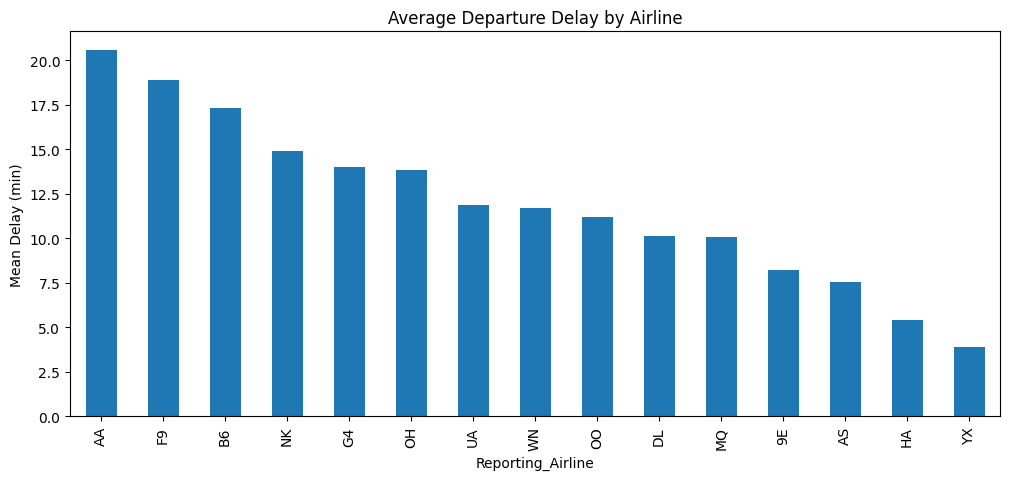

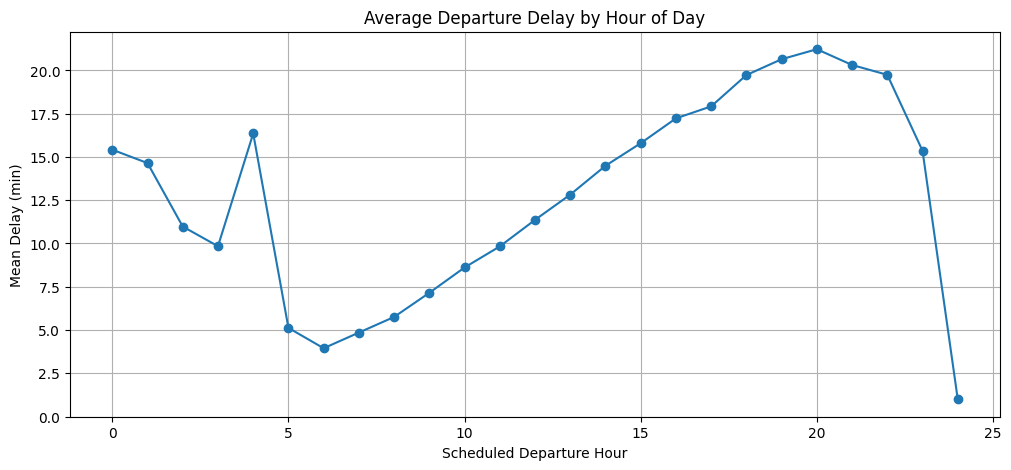

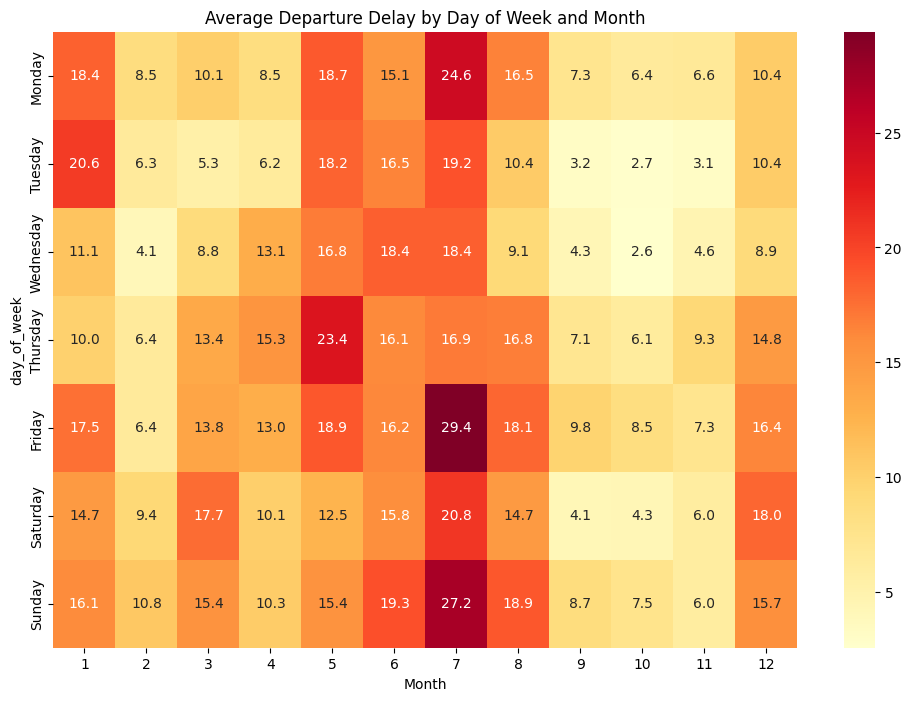

In [ ]:
# Feature Engineering: dep_hour and day_of_week
df['dep_hour'] = df['CRSDepTime'] // 100
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
df['day_of_week'] = df['FlightDate'].dt.day_name()

# Mean delay by Reporting_Airline
plt.figure(figsize=(12, 5))
df.groupby('Reporting_Airline')['DepDelay'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Departure Delay by Airline')
plt.ylabel('Mean Delay (min)')
plt.show()

# Mean delay by dep_hour
plt.figure(figsize=(12, 5))
df.groupby('dep_hour')['DepDelay'].mean().plot(marker='o')
plt.title('Average Departure Delay by Hour of Day')
plt.xlabel('Scheduled Departure Hour')
plt.ylabel('Mean Delay (min)')
plt.grid(True)
plt.show()

# Heatmap: month × day_of_week average delay
pivot_df = df.pivot_table(index='day_of_week', columns='Month', values='DepDelay', aggfunc='mean')
# Sort days of week
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_df = pivot_df.reindex(days)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap='YlOrRd')
plt.title('Average Departure Delay by Day of Week and Month')
plt.show()

#### Average Departure Delay by Airline
Departure delays vary considerably across carriers. The bar chart shows that some airlines consistently average over 18-20 minutes of delay, while the best-performing carriers average as low as 3-5 minutes. This suggests that carrier-specific operational factors, such as fleet size, hub congestion, and scheduling practices, may play a significant role in delay performance.

#### Average Departure Delay by Hour of Day
The line chart reveals a clear time-of-day effect on delays:
- Delays are moderate in the early morning hours (aroudn midnight) at roughly 15 minutes, then drop sharply to their lowest point around 5:00-6:00 AM, which is most likely when the airports are least congested.
- From there, delays rise steadily throughout the day as the ripple effect of earlier delays may accumulate across the network.
- Delays seem to peak aroudn 8:00-9:00 PM, reflecting the accumulated impact of a full day of operations.
- A sharp drop occurs after 11:00 PM, as fewer flights operate late at night.
This pattern is consistent with the well-known aviation concept of **delay propagation**, where late arrivals from earlier flights cause subsequent departures to be delayed. 

#### Average Departure Delay by Day of Week and Month
The heatmap provides a combined view of how delays interact across days and months:
- **July (Month 7)** stands out as the worst month overall, with notably high delays across nearly every day of the week. Friday in July peaks at **29.4 minutes**, the highest cell in the entire grid.
- **June (Month 6)** also shows elevated delays, particularly on Thursdays (23.4 min) and Mondays (24.6 min), which is consistent with summer travel demand.
- **Weekends (Saturday & Sunday)** tend to perform slightly better than weekdays in most months, posibly due to lower business travel volume.
- **Winter months (September-November)** show the lowest delays across the board, appearing in lighter yellow tones throughout.


Together, these three charts suggest that **airline choice, time of departure, and travel season** are all meaningful predictors of departure delay.

### Data Quality Check

Before proceeding with analysis, a data quality check was performed to identify missing values, extreme outliers, and invalid entries. 

In [6]:
# Total number of flights
print(f"Total number of flights: {len(df)}")
print(df.shape[0])

# Remaining nulls?
print("Missing values in dataset:")
print(df.isnull().sum())

# DepDelay > 500 min? (likely data errors or extreme outliers)
extreme_delays = df[df['DepDelay'] > 500]
print(f"\nNumber of flights with delay > 500 min: {len(extreme_delays)}")

# CRSDepTime values outside 0–2359?
invalid_times = df[(df['CRSDepTime'] < 0) | (df['CRSDepTime'] > 2359)]
print(f"Number of flights with invalid CRSDepTime: {len(invalid_times)}")

Total number of flights: 6965247
6965247
Missing values in dataset:
Year                       0
Quarter                    0
Month                      0
FlightDate                 0
Reporting_Airline          0
Origin                     0
Dest                       0
CRSDepTime                 0
CRSArrTime                 0
DepDelay                   0
Cancelled                  0
CancellationCode     6965247
Diverted                   0
Distance                   0
dep_hour                   0
day_of_week                0
dtype: int64

Number of flights with delay > 500 min: 13657
Number of flights with invalid CRSDepTime: 1


#### Missing Values
Almost all columns are fully complete with zero missing values. The one exception is **CancellationCode**, which has **6,965,247 missing entries**. This is expected and not an error in the data, as cancellation codes only apply to flights that were actually cancelled. Non-cancelled flights naturally have no value in this field.

#### Extreme Delay Outliers
A total of **13,657 flights** recorded a departure delay exceeding **500 minutes**(~8 hours). These represent either genuine extreme delay events (i.e. outliers) or potential data entry errors. Depending on the modeling approach, these may need to be capped or excluded to prevent them from distorting the analysis.

#### Invalid Schedule Departure Times
Only 1 flight was foudn with a CRSDepTime value outside the valid range of 0-2359, whcih is negligible. This entry can be safely dropped or corrected without meaningfully affecting the dataset.

#### Overall Assessment
The dataset is in good condition overall. The main concerns for the extreme delays and the single invalid time entry are minor relative to the full dataset size, and the missing CancellationCode values are structurally expected rather than indicative of data quality issues. 